In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
%matplotlib inline

df = pd.read_csv('/content/indian_roads_dataset.csv')
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


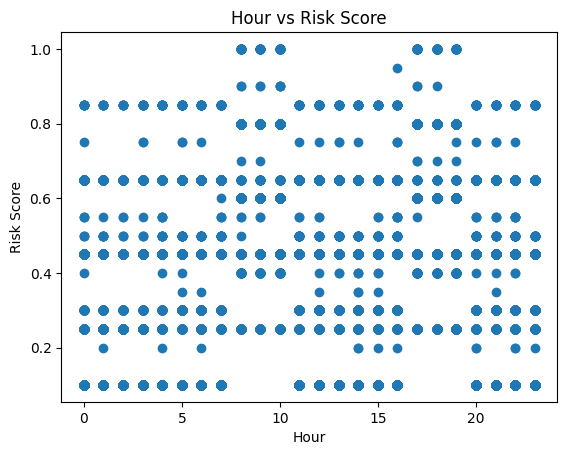

In [2]:
plt.scatter(df['hour'], df['risk_score'])
plt.xlabel('Hour')
plt.ylabel('Risk Score')
plt.title('Hour vs Risk Score')
plt.show()

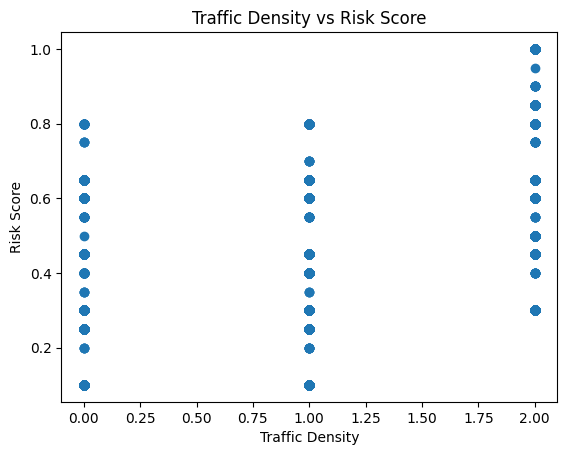

In [3]:
# Convert traffic density to numbers first
df['traffic_density_num'] = df['traffic_density'].map({
    'high': 2, 'medium': 1, 'low': 0
})

plt.scatter(df['traffic_density_num'], df['risk_score'])
plt.xlabel('Traffic Density')
plt.ylabel('Risk Score')
plt.title('Traffic Density vs Risk Score')
plt.show()

In [4]:
# Convert categorical columns
df['road_type_num'] = df['road_type'].map({'highway': 2, 'urban': 1, 'rural': 0})
df['weather_num'] = df['weather'].map({'fog': 2, 'rain': 1, 'clear': 0})
df['visibility_num'] = df['visibility'].map({'low': 2, 'medium': 1, 'high': 0})

# Input
X = df[['hour', 'traffic_density_num']]

# Output
y = df['risk_score']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000, 2)
y shape: (20000,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (14000, 2)
X_test shape: (6000, 2)
y_train shape: (14000,)
y_test shape: (6000,)


In [6]:
print("X_train:")
print(X_train.head())

print("\nX_test:")
print(X_test.head())

print("\ny_train:")
print(y_train.head())

print("\ny_test:")
print(y_test.head())

X_train:
       hour  traffic_density_num
16642     7                    2
4425      9                    2
15468    16                    2
13479     7                    1
2685      6                    0

X_test:
       hour  traffic_density_num
2050      7                    1
16362     4                    0
14168     0                    0
16133     0                    0
12162     9                    2

y_train:
16642    0.45
4425     0.80
15468    0.30
13479    0.45
2685     0.10
Name: risk_score, dtype: float64

y_test:
2050     0.45
16362    0.65
14168    0.65
16133    0.10
12162    0.80
Name: risk_score, dtype: float64


In [7]:
clf = LinearRegression()
clf.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


In [8]:
predictions = clf.predict(X_test)
print("Predictions:")
print(predictions[:6])

print("\nActual values:")
print(y_test[:6].values)

Predictions:
[0.43771428 0.31111551 0.31162364 0.31162364 0.56444009 0.43631693]

Actual values:
[0.45 0.65 0.65 0.1  0.8  0.8 ]


In [9]:
score = clf.score(X_test, y_test)
print("Model Score:", round(score, 3))

Model Score: 0.249


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=10
)
print("X_test with random_state=10:")
print(X_test.head())

X_test with random_state=10:
       hour  traffic_density_num
19778    20                    2
4376     12                    0
10188    10                    2
9887     16                    2
4441     13                    2
